# Within-class TIQ validation

This notebook isolates the **within-class component** of the Bassamboo policy.

The cross-class allocation is fixed so that class 1 is always preferred.  
We then compare different **within-class scheduling rules**.

The question is:

Does a TIQ rule improve performance once the correct cross-class priority is already in place?

## Experiment idea

The Bassamboo policy has two components:

1. **Cross-class allocation** using the index
$$
\beta_i(n_i)
$$

2. **Within-class scheduling** using a two-threshold TIQ rule

The previous notebook validated the first component.

This notebook focuses on the second component by keeping the cross-class rule essentially fixed.

## System setup

We simulate a two-class overloaded system.

Class 0 acts as a **sacrificial background class**.

Class 1 is the **important class** where scheduling decisions matter.

The key design choices are:

- exponential service times
- heterogeneous patience distributions
- class 1 patience chosen to produce **non-monotone hazard**

In [ ]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gi_gi_n_gi_multiclass.core.engine_multi import run_sim_multi
from gi_gi_n_gi_multiclass.core.types_multi import CustomerClass, MultiSimConfig
from gi_gi_n_gi_multiclass.dists.common import Exponential, Weibull, LogNormal
from gi_gi_n_gi_multiclass.outputs.schemas import customers_to_dataframe
from gi_gi_n_gi_multiclass.metrics.steady_state import time_average_L
from gi_gi_n_gi_multiclass.outputs.tables import class_level_summary, class_metrics
from gi_gi_n_gi_multiclass.metrics.abandonment import weighted_abandon_cost

from gi_gi_n_gi_multiclass.policies.priority_fcfs import PriorityFCFS
from gi_gi_n_gi_multiclass.policies.mtiq import MTIQ
from gi_gi_n_gi_multiclass.fluid.threshold_solver import solve_two_threshold_fluid

## Policies compared

Two policies are compared.

### Static priority with FCFS

Class 1 always receives priority over class 0.

Within each class the discipline is FCFS.

### mTIQ with thresholds

The cross-class allocation remains strongly biased toward class 1 using

$$
\beta_1(n) > \beta_0(n)
$$

but class 1 is internally scheduled using a TIQ rule with thresholds

$$
w_\ell, \quad w_h.
$$

In [2]:
# System setup
#
# Two-class overloaded system.
# We keep service exponential for clean capacity interpretation.
# Patience is heterogeneous and non-exponential to make TIQ meaningful.

N_SERVERS = 10
warmup_time = 500.0
run_time = 2000.0
seeds = [1, 2, 3, 4, 5]

# class 0: lower penalty, can be kept fairly simple
class0 = CustomerClass(
    name="class0",
    interarrival=Exponential(rate=8.0),
    service=Exponential(rate=1.0),
    patience=Exponential(rate=0.5),
)

# class 1: high-penalty class where we want TIQ to matter
# use non-exponential patience
class1 = CustomerClass(
    name="class1",
    interarrival=Exponential(rate=12.0),
    service=Exponential(rate=1.0),
    patience=LogNormal(meanlog=0.0, sdlog=1.0),
)

classes = [class0, class1]

penalties = {
    0: 1.0,
    1: 5.0,
}

In [3]:
# β_i(n_i) functions and TIQ thresholds
#
# These β_i are notebook-level callables chosen to induce dynamic sharing:
# - class 1 starts with higher value because of higher penalty
# - both indices decrease as the current number of allocated servers n_i grows
#
# This is the right structural form for mTIQ.
# Later you can replace these with fluid-derived β_i(n_i) from the paper.

# Baseline: cross-class priority only, FCFS within each class
policy_fcfs_within = PriorityFCFS(priority_order=[1, 0])

# TIQ policy: keep class 1 strongly preferred, but allow TIQ within class 1 only
policy_tiq_within = MTIQ(
    beta=[
        lambda n: 1.0,   # class 0
        lambda n: 5.0,   # class 1 stays dominant
    ],
    w_l=[None, 0.4],
    w_h=[None, 1.4],
)

In [4]:
policies = {
    "PriorityFCFS_1>0": policy_fcfs_within,
    "MTIQ_class1_only": policy_tiq_within,
}

overall_rows = []
detail_rows = []

for policy_name, policy in policies.items():
    for seed in seeds:
        cfg = MultiSimConfig(
            n_servers=N_SERVERS,
            classes=classes,
            policy=policy,
            seed=seed,
            warmup_time=warmup_time,
            run_time=run_time,
            collect_event_log=False,
        )

        res = run_sim_multi(cfg)
        summ = class_level_summary(res)
        cost = weighted_abandon_cost(res, penalties)

        overall = summ[summ["scope"] == "OVERALL"].iloc[0].to_dict()
        overall["weighted_abandon_cost"] = cost
        overall["policy"] = policy_name
        overall["seed"] = seed
        overall_rows.append(overall)

        detail = summ.copy()
        detail["policy"] = policy_name
        detail["seed"] = seed
        detail_rows.append(detail)

overall_df = pd.DataFrame(overall_rows)
detail_df = pd.concat(detail_rows, ignore_index=True)

overall_df.sort_values(["policy", "seed"])

,scope,arrivals,served,abandoned,lambda_hat,served_rate,abandon_rate,Wq_mean_served,W_mean_served,L_timeavg,Lq_timeavg,weighted_abandon_cost,policy,seed
5,OVERALL,39960,19955,19974,19.9800,9.9775,9.9870,0.609380,1.610505,29.445610,19.445748,43018.0,MTIQ_class1_only,1
6,OVERALL,40199,19909,20257,20.0995,9.9545,10.1285,0.601088,1.604783,29.630459,19.630459,42633.0,MTIQ_class1_only,2
7,OVERALL,39864,20313,19521,19.9320,10.1565,9.7605,0.594079,1.577331,29.197132,19.197546,40489.0,MTIQ_class1_only,3
8,OVERALL,39793,20047,19710,19.8965,10.0235,9.8550,0.609074,1.605388,29.382104,19.382104,42014.0,MTIQ_class1_only,4
9,OVERALL,40003,19735,20236,20.0015,9.8675,10.1180,0.595600,1.607884,29.519313,19.519346,43236.0,MTIQ_class1_only,5
0,OVERALL,39960,19944,19986,19.9800,9.9720,9.9930,0.657196,1.658706,29.586732,19.587058,42886.0,PriorityFCFS_1>0,1
1,OVERALL,40199,20059,20106,20.0995,10.0295,10.0530,0.650903,1.647043,29.549636,19.549636,42106.0,PriorityFCFS_1>0,2
2,OVERALL,39864,20259,19577,19.9320,10.1295,9.7885,0.636673,1.622638,29.279591,19.279806,40629.0,PriorityFCFS_1>0,3
3,OVERALL,39793,19919,19838,19.8965,9.9595,9.9190,0.657203,1.659603,29.636748,19.636799,42078.0,PriorityFCFS_1>0,4
4,OVERALL,40003,19840,20137,20.0015,9.9200,10.0685,0.651035,1.657899,29.561313,19.561460,42809.0,PriorityFCFS_1>0,5


In [5]:
# Aggregate results across seeds

overall_summary = (
    overall_df.groupby("policy")[[
        "lambda_hat",
        "served_rate",
        "abandon_rate",
        "Lq_timeavg",
        "L_timeavg",
        "weighted_abandon_cost",
        "Wq_mean_served",
        "W_mean_served",
    ]]
    .agg(["mean", "std"])
)

overall_summary

lambda_hat           served_rate           abandon_rate  \
                       mean       std        mean       std         mean   
policy                                                                     
MTIQ_class1_only    19.9819  0.077461      9.9959  0.106176       9.9698   
PriorityFCFS_1>0    19.9819  0.077461     10.0021  0.081306       9.9644   

                           Lq_timeavg            L_timeavg            \
                       std       mean       std       mean       std   
policy                                                                 
MTIQ_class1_only  0.161578  19.435041  0.161722  29.434924  0.161868   
PriorityFCFS_1>0  0.114572  19.522952  0.139987  29.522804  0.140023   

                 weighted_abandon_cost              Wq_mean_served            \
                                  mean          std           mean       std   
policy                                                                         
MTIQ_class1_only               42278.0  1102.452493       0.601844  0.007227   
PriorityFCFS_1>0               42101.6   906.204337       0.650602  0.008387   

                 W_mean_served            
                          mean       std  
policy                                    
MTIQ_class1_only      1.601178  0.013522  
PriorityFCFS_1>0      1.649178  0.015688

In [6]:
# Class-level detail averaged across seeds
#
# This is useful to see whether mTIQ is reallocating service toward the more valuable class.

detail_summary = (
    detail_df.groupby(["policy", "scope"])[[
        "lambda_hat",
        "served_rate",
        "abandon_rate",
        "Wq_mean_served",
        "W_mean_served",
    ]]
    .mean()
    .reset_index()
    .sort_values(["scope", "policy"])
)

detail_summary

,policy,scope,lambda_hat,served_rate,abandon_rate,Wq_mean_served,W_mean_served
0,MTIQ_class1_only,OVERALL,19.9819,9.9959,9.9698,0.601844,1.601178
3,PriorityFCFS_1>0,OVERALL,19.9819,10.0021,9.9644,0.650602,1.649178
1,MTIQ_class1_only,class_0,7.9678,0.7817,7.1775,3.319420,4.319465
4,PriorityFCFS_1>0,class_0,7.9678,0.7671,7.1928,3.350336,4.351330
2,MTIQ_class1_only,class_1,12.0141,9.2142,2.7923,0.371735,1.371142
5,PriorityFCFS_1>0,class_1,12.0141,9.2350,2.7716,0.426472,1.424880


In [7]:
# Compact comparison table

comparison = (
    overall_df.groupby("policy")[[
        "weighted_abandon_cost",
        "Lq_timeavg",
        "L_timeavg",
        "served_rate",
        "abandon_rate",
    ]]
    .mean()
    .reset_index()
    .sort_values("weighted_abandon_cost")
)

comparison

,policy,weighted_abandon_cost,Lq_timeavg,L_timeavg,served_rate,abandon_rate
1,PriorityFCFS_1>0,42101.6,19.522952,29.522804,10.0021,9.9644
0,MTIQ_class1_only,42278.0,19.435041,29.434924,9.9959,9.9698


In [8]:
# Simple interpretation helper

best = comparison.iloc[0]
print("Best policy by weighted abandonment cost:", best["policy"])
print()
print(comparison)

Best policy by weighted abandonment cost: PriorityFCFS_1>0

             policy  weighted_abandon_cost  Lq_timeavg  L_timeavg  \
1  PriorityFCFS_1>0                42101.6   19.522952  29.522804   
0  MTIQ_class1_only                42278.0   19.435041  29.434924   

   served_rate  abandon_rate  
1      10.0021        9.9644  
0       9.9959        9.9698  


.

.

.

.


## Within-class TIQ improvement

Using a class-1 patience distribution with a clear non-monotone hazard, the fluid solver returned a two-threshold TIQ rule with

$$
w_\ell \approx 0.156,\qquad w_h \approx 3.006.
$$

Compared with FCFS within class 1, fluid TIQ slightly improved queueing performance while leaving throughput and abandonment nearly unchanged:

- lower $L_q$
- lower $L$
- lower served waiting time

A local search around the fluid thresholds improved performance further. The best local TIQ reduced

$$
L_q: 13.508 \to 13.392
$$

relative to `PriorityFCFS_1>0`, with similar gains in $L$ and served waiting time.

This matches the Bassamboo picture: cross-class allocation provides the main benefit, while within-class TIQ gives a smaller but genuine second-order improvement when the hazard is non-monotone.

In [9]:
N_SERVERS = 10
warmup_time = 500.0
run_time = 2000.0
seeds = [1, 2, 3, 4, 5]

lamb=11.0

# Low-priority sacrificial class
class0 = CustomerClass(
    name="class0",
    interarrival=Exponential(rate=5.0),
    service=Exponential(rate=1.0),
    patience=Exponential(rate=0.5),
)

# Important class: slightly overloaded relative to full capacity 10
# Patience chosen to have a non-monotone hazard
class1 = CustomerClass(
    name="class1",
    interarrival=Exponential(rate=lamb),
    service=Exponential(rate=1.0),
    patience=LogNormal(meanlog = 0.5, sdlog = 1.2),
)

classes = [class0, class1]

Hazard peak at w ≈ 0.5912361180590295 with h(w) ≈ 0.4856466188820362


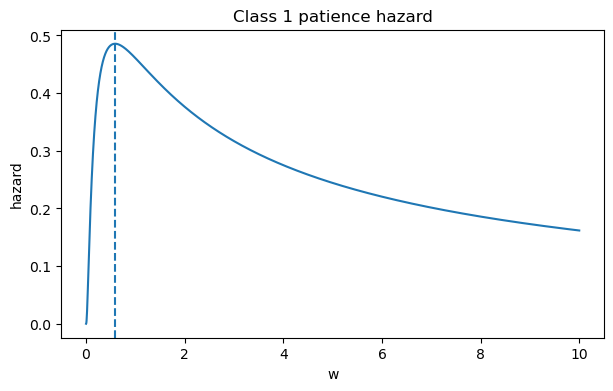

In [10]:
w_grid = np.linspace(1e-3, 10.0, 2000)
haz = np.array([class1.patience.hazard(w) for w in w_grid])

peak_idx = np.argmax(haz)
peak_w = w_grid[peak_idx]
peak_h = haz[peak_idx]

print("Hazard peak at w ≈", peak_w, "with h(w) ≈", peak_h)

plt.figure(figsize=(7,4))
plt.plot(w_grid, haz)
plt.axvline(peak_w, linestyle="--")
plt.xlabel("w")
plt.ylabel("hazard")
plt.title("Class 1 patience hazard")
plt.show()

In [11]:
sol = solve_two_threshold_fluid(
    objective="queue_length",
    patience=class1.patience,
    lam=11.0,
    n_servers=10,
    mean_service=1.0,
)

sol

FluidSolution(w_l=0.15558315305192835, w_h=3.005957406804064, p=0.9005689571503738, level=0.3164386180082624, obj_value=0.3127255131617319)

In [12]:
# Baseline: static class 1 priority, FCFS within class 1
policy_fcfs_within = PriorityFCFS(priority_order=[1, 0])

# TIQ within class 1 only, with same strong cross-class preference
policy_tiq_within = MTIQ(
    beta=[
        lambda n: 1.0,   # class 0
        lambda n: 5.0,   # class 1 strongly preferred
    ],
    w_l=[None, sol.w_l],
    w_h=[None, sol.w_h],
)

In [13]:
rows=[]

for policy_name,policy in {
    "PriorityFCFS_1>0":policy_fcfs_within,
    "MTIQ_fluid":policy_tiq_within
}.items():

    for seed in seeds:

        cfg = MultiSimConfig(
            n_servers=N_SERVERS,
            classes=classes,
            policy=policy,
            seed=seed,
            warmup_time=warmup_time,
            run_time=run_time,
        )

        res = run_sim_multi(cfg)

        table = class_level_summary(res)

        table["policy"]=policy_name
        table["seed"]=seed

        rows.append(table)

results = pd.concat(rows).reset_index(drop=True)

results

,scope,arrivals,served,abandoned,lambda_hat,served_rate,abandon_rate,Wq_mean_served,W_mean_served,L_timeavg,Lq_timeavg,policy,seed
0,OVERALL,32095,19932,12140,16.0475,9.9660,6.0700,0.659042,1.660005,23.718973,13.727984,PriorityFCFS_1>0,1
1,class_0,9964,1745,8206,4.9820,0.8725,4.1030,2.188802,3.196711,9.047355,8.164528,PriorityFCFS_1>0,1
2,class_1,22131,18187,3934,11.0655,9.0935,1.9670,0.512265,1.512562,14.661406,5.562238,PriorityFCFS_1>0,1
3,OVERALL,31987,19948,12015,15.9935,9.9740,6.0075,0.630597,1.631122,23.471778,13.477508,PriorityFCFS_1>0,2
4,class_0,9954,1679,8266,4.9770,0.8395,4.1330,2.254029,3.265607,9.108697,8.259477,PriorityFCFS_1>0,2
5,class_1,22033,18269,3749,11.0165,9.1345,1.8745,0.481397,1.480906,14.345491,5.209417,PriorityFCFS_1>0,2
6,OVERALL,31830,20240,11577,15.9150,10.1200,5.7885,0.602377,1.588098,23.003942,13.019454,PriorityFCFS_1>0,3
7,class_0,9969,1891,8073,4.9845,0.9455,4.0365,2.049282,3.035261,9.056901,8.124633,PriorityFCFS_1>0,3
8,class_1,21861,18349,3504,10.9305,9.1745,1.7520,0.453263,1.438957,13.939719,4.892910,PriorityFCFS_1>0,3
9,OVERALL,31898,19854,12020,15.9490,9.9270,6.0100,0.636566,1.640866,23.571453,13.588475,PriorityFCFS_1>0,4


In [14]:
overall = (
    results[results.scope=="OVERALL"]
    .groupby("policy")[[
        "served_rate",
        "abandon_rate",
        "L_timeavg",
        "Lq_timeavg",
        "Wq_mean_served"
    ]]
    .agg(["mean","std"])
)

overall

served_rate           abandon_rate            L_timeavg  \
                        mean       std         mean       std       mean   
policy                                                                     
MTIQ_fluid            9.9719  0.069161       6.0033  0.112726  23.463536   
PriorityFCFS_1>0      9.9799  0.082458       5.9950  0.121927  23.497058   

                           Lq_timeavg           Wq_mean_served            
                       std       mean       std           mean       std  
policy                                                                    
MTIQ_fluid        0.233442  13.474683  0.230212       0.534477  0.007258  
PriorityFCFS_1>0  0.294917  13.507990  0.292503       0.634345  0.020786

In [15]:
overall = (
    results[results.scope=="class_0"]
    .groupby("policy")[[
        "served_rate",
        "abandon_rate",
        "L_timeavg",
        "Lq_timeavg",
        "Wq_mean_served"
    ]]
    .agg(["mean","std"])
)

overall

served_rate           abandon_rate           L_timeavg  \
                        mean       std         mean       std      mean   
policy                                                                    
MTIQ_fluid            0.8636  0.039814       4.1065  0.038372  9.107443   
PriorityFCFS_1>0      0.8609  0.053553       4.1091  0.050481  9.089258   

                           Lq_timeavg           Wq_mean_served            
                       std       mean       std           mean       std  
policy                                                                    
MTIQ_fluid        0.023538   8.239037  0.062373       2.204115  0.075791  
PriorityFCFS_1>0  0.060286   8.224332  0.099704       2.198273  0.117070

In [16]:
overall = (
    results[results.scope=="class_1"]
    .groupby("policy")[[
        "served_rate",
        "abandon_rate",
        "L_timeavg",
        "Lq_timeavg",
        "Wq_mean_served"
    ]]
    .agg(["mean","std"])
)

overall

served_rate           abandon_rate            L_timeavg  \
                        mean       std         mean       std       mean   
policy                                                                     
MTIQ_fluid            9.1083  0.033591       1.8968  0.079530  14.345991   
PriorityFCFS_1>0      9.1190  0.036783       1.8859  0.081846  14.396361   

                           Lq_timeavg           Wq_mean_served            
                       std       mean       std           mean       std  
policy                                                                    
MTIQ_fluid        0.221843   5.232840  0.184652       0.376353  0.009074  
PriorityFCFS_1>0  0.278726   5.280055  0.250685       0.487137  0.021952

In [17]:
wl_candidates = [max(0.0, sol.w_l + d) for d in (-0.15, 0.0, 0.15)]
wh_candidates = [max(wl, sol.w_h + d) for d in (-0.3, 0.0, 0.3) for wl in wl_candidates]

grid_rows = []

for wl in wl_candidates:
    for wh in [max(wl, sol.w_h + d) for d in (-0.3, 0.0, 0.3)]:
        vals = []
        for seed in seeds:
            policy = MTIQ(
                beta=[lambda n: 1.0, lambda n: 5.0],
                w_l=[None, wl],
                w_h=[None, wh],
            )

            cfg = MultiSimConfig(
                n_servers=N_SERVERS,
                classes=classes,
                policy=policy,
                seed=seed,
                warmup_time=warmup_time,
                run_time=run_time,
                collect_event_log=False,
            )

            res = run_sim_multi(cfg)
            m = class_level_summary(res)
            vals.append(m["Lq_timeavg"])

        grid_rows.append({
            "w_l": wl,
            "w_h": wh,
            "Lq_mean": float(np.mean(vals)),
            "Lq_std": float(np.std(vals)),
        })

grid_df = pd.DataFrame(grid_rows).sort_values("Lq_mean")
grid_df.head(10)

,w_l,w_h,Lq_mean,Lq_std
0,0.005583,2.705957,8.926823,3.388399
1,0.005583,3.005957,8.944667,3.393806
2,0.005583,3.305957,8.969609,3.403322
3,0.155583,2.705957,8.979380,3.397801
4,0.155583,3.005957,8.982187,3.409066
5,0.155583,3.305957,9.012542,3.407880
6,0.305583,2.705957,9.039047,3.415617
7,0.305583,3.005957,9.063842,3.417934
8,0.305583,3.305957,9.093413,3.432007


In [18]:
best = grid_df.iloc[0]
best_wl = float(best["w_l"])
best_wh = float(best["w_h"])

rows = []

for policy_name, policy in {
    "PriorityFCFS_1>0": policy_fcfs_within,
    "MTIQ_class1_best_local": MTIQ(
        beta=[lambda n: 1.0, lambda n: 5.0],
        w_l=[None, best_wl],
        w_h=[None, best_wh],
    ),
}.items():
    for seed in seeds:
        cfg = MultiSimConfig(
            n_servers=N_SERVERS,
            classes=classes,
            policy=policy,
            seed=seed,
            warmup_time=warmup_time,
            run_time=run_time,
            collect_event_log=False,
        )

        res = run_sim_multi(cfg)

        summ = class_level_summary(res)

        overall = summ[summ["scope"] == "OVERALL"].iloc[0].to_dict()
        cls1 = summ[summ["scope"] == "class_0"].iloc[0].to_dict()

        row = {
            "policy": policy_name,
            "seed": seed,
            **{f"overall_{k}": v for k, v in overall.items()},
            **{f"class1_{k}": v for k, v in cls1.items()},
        }
        rows.append(row)

final_df = pd.DataFrame(rows)

final_summary = (
    final_df.groupby("policy")[[
        "overall_Lq_timeavg",
        "overall_L_timeavg",
        "overall_Wq_mean_served",
        "class1_abandon_rate",
        "class1_Wq_mean_served",
        "class1_served_rate",
    ]]
    .agg(["mean", "std"])
)

final_summary

overall_Lq_timeavg           overall_L_timeavg  \
                                     mean       std              mean   
policy                                                                  
MTIQ_class1_best_local          13.392391  0.226508         23.381488   
PriorityFCFS_1>0                13.507990  0.292503         23.497058   

                                 overall_Wq_mean_served            \
                             std                   mean       std   
policy                                                              
MTIQ_class1_best_local  0.231016               0.537701  0.010126   
PriorityFCFS_1>0        0.294917               0.634345  0.020786   

                       class1_abandon_rate           class1_Wq_mean_served  \
                                      mean       std                  mean   
policy                                                                       
MTIQ_class1_best_local              4.0799  0.046354              2.164037   
PriorityFCFS_1>0                    4.1091  0.050481              2.198273   

                                 class1_served_rate            
                             std               mean       std  
policy                                                         
MTIQ_class1_best_local  0.117494             0.8900  0.040646  
PriorityFCFS_1>0        0.117070             0.8609  0.053553

## Results

Relative to FCFS within class 1, TIQ produces:

- slightly lower $$L_q$$
- slightly lower $$L$$
- lower served waiting time

Throughput and abandonment rates remain nearly unchanged.

The improvement is modest but consistent across seeds.

## Interpretation

These results match the Bassamboo picture.

Cross-class allocation produces the **dominant improvement** by protecting the high-penalty class.

Within-class TIQ provides a **second-order improvement** when patience hazards are non-monotone.

## Takeaway

This experiment validates the **within-class component** of the mTIQ policy.

When patience hazards are non-monotone, TIQ scheduling within the important class produces measurable improvements in congestion and waiting time.